# ML Foundations — Problem Framing, Hold-Out Test & Baseline
**Dataset:** UCI "Adult" (Census Income) — predicting whether an individual earns **>50K/year**
**Date:** 31 Aug 2026

This notebook covers: problem framing → EDA → reproducible train/hold-out split → simple baselines → error analysis → next steps.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, confusion_matrix,
                              ConfusionMatrixDisplay)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
np.random.seed(RANDOM_STATE)

## Task 1 — Problem Definition & Success Metric

**Target definition:** `income = 1` if the individual earns **>50K/year** (positive class), else `0`.

**Business objective:** This mirrors a *targeted marketing / outreach* use case — e.g. a financial services company wants to identify higher-income individuals to offer a premium product, while a sales team only has budget to contact a limited number of leads. Contacting a low-income lead wastes a sales rep's time and marketing spend; missing a genuine high-income lead is a smaller loss (the segment is large, so some missed opportunities are tolerable).

**Chosen primary metric: Precision** (of the individuals we flag as `>50K`, what fraction actually are?), evaluated alongside **ROC AUC** as a threshold-independent secondary metric for model comparison.

**Why precision over recall:** Outreach has a real per-contact cost (rep time, mailer cost, risk of annoying the wrong audience). Because the positive class is a minority (~24%), a model that chases recall will drag in many false positives, so we weight precision higher — we would rather contact fewer people and have most of them qualify, than blanket-contact everyone and waste effort. Recall is not ignored (we don't want to miss *too many* good leads), but precision is the primary metric because it directly controls wasted-outreach cost, which is the business's stated pain point.

**Plain-language summary for a stakeholder:** *"We're building a model to flag which individuals in our contact list are likely high earners, so the sales team can prioritize outreach. We're optimizing so that when the model says 'contact this person,' it's usually right — that keeps the team from wasting time on the wrong leads, even if it means occasionally skipping a good lead."*

In [2]:
base_rate = None  # computed after load in Task 2, referenced here for narrative continuity
print("Metric: Precision (primary), ROC AUC (secondary)")

Metric: Precision (primary), ROC AUC (secondary)


## Task 2 — Data Load & Quick EDA

Loading the UCI Adult dataset (48,842 rows, 14 features + target). Network access to `openml.org` / the UCI repository was unavailable in this environment, so the dataset was retrieved from the well-known, unmodified mirror `jbrownlee/Datasets` (raw UCI columns, same values/semantics as `fetch_openml('adult')`). The loader below is written so it can be swapped for `fetch_openml('adult', version=2, as_frame=True)` directly with no other code changes if you have open internet access.

In [3]:
COLS = ["age","workclass","fnlwgt","education","education-num","marital-status",
        "occupation","relationship","race","sex","capital-gain","capital-loss",
        "hours-per-week","native-country","income"]

# --- Option A: sklearn (use this if you have internet access) ---
# from sklearn.datasets import fetch_openml
# adult = fetch_openml('adult', version=2, as_frame=True)
# df = adult.frame
# df = df.rename(columns={'class': 'income'})

# --- Option B: raw UCI-format CSV (used here) ---
df = pd.read_csv("adult-all.csv", header=None, names=COLS, na_values="?", skipinitialspace=True)

# Binary target: >50K -> 1, <=50K -> 0. Strip any trailing '.' gotcha from raw UCI test file.
df["income"] = df["income"].astype(str).str.strip().str.rstrip(".")
df["target"] = (df["income"] == ">50K").astype(int)

print(f"Shape: {df.shape}")
df.head()

Shape: (48842, 16)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0


In [4]:
# Data shape & column types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       46043 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      46033 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  47985 non-null  str  
 14  income          48842 non-null  str  
 15  target          48842 non-null  int64
dtypes: int64(7), str(9)
memory usage: 6.0 MB


In [5]:
# Missing values (converted from '?' to NaN on load)
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)
print(f"\nRows with at least one missing value: {df.isna().any(axis=1).sum()} ({df.isna().any(axis=1).mean():.1%})")

Columns with missing values:
occupation        2809
workclass         2799
native-country     857
dtype: int64

Rows with at least one missing value: 3620 (7.4%)


In [6]:
# Numeric summaries
numeric_cols = ["age","fnlwgt","education-num","capital-gain","capital-loss","hours-per-week"]
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


In [7]:
# Value counts for key categorical columns
for col in ["workclass","education","marital-status","occupation","sex","native-country"]:
    print(f"\n--- {col} (top 5) ---")
    print(df[col].value_counts(dropna=False).head(5))


--- workclass (top 5) ---
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
NaN                  2799
State-gov            1981
Name: count, dtype: int64

--- education (top 5) ---
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
Name: count, dtype: int64

--- marital-status (top 5) ---
marital-status
Married-civ-spouse    22379
Never-married         16117
Divorced               6633
Separated              1530
Widowed                1518
Name: count, dtype: int64

--- occupation (top 5) ---
occupation
Prof-specialty     6172
Craft-repair       6112
Exec-managerial    6086
Adm-clerical       5611
Sales              5504
Name: count, dtype: int64

--- sex (top 5) ---
sex
Male      32650
Female    16192
Name: count, dtype: int64

--- native-country (top 5) ---
native-country
United-States    43832
Mexico             951
NaN                857
Philippines        295
Germany       

In [8]:
# Class balance -> base rate
class_counts = df["target"].value_counts().rename({0: "<=50K", 1: ">50K"})
base_rate = df["target"].mean()
print(class_counts)
print(f"\nBase rate (positive class, >50K): {base_rate:.3%}")

target
<=50K    37155
>50K     11687
Name: count, dtype: int64

Base rate (positive class, >50K): 23.928%


In [9]:
# Summary table: class counts + 3 notable feature distributions
summary_table = pd.DataFrame({
    "count": class_counts,
    "pct": (class_counts / len(df)).round(4)
})
print("Class balance summary")
display(summary_table)

feature_summary = pd.DataFrame({
    "age_mean": df.groupby("income")["age"].mean(),
    "education_num_mean": df.groupby("income")["education-num"].mean(),
    "hours_per_week_mean": df.groupby("income")["hours-per-week"].mean(),
    "capital_gain_mean": df.groupby("income")["capital-gain"].mean(),
}).round(2)
print("\nNotable feature distributions by class")
display(feature_summary)

Class balance summary


,count,pct
target,,
<=50K,37155,0.7607
>50K,11687,0.2393



Notable feature distributions by class


,age_mean,education_num_mean,hours_per_week_mean,capital_gain_mean
income,,,,
<=50K,36.87,9.6,38.84,147.01
>50K,44.28,11.6,45.45,4042.24


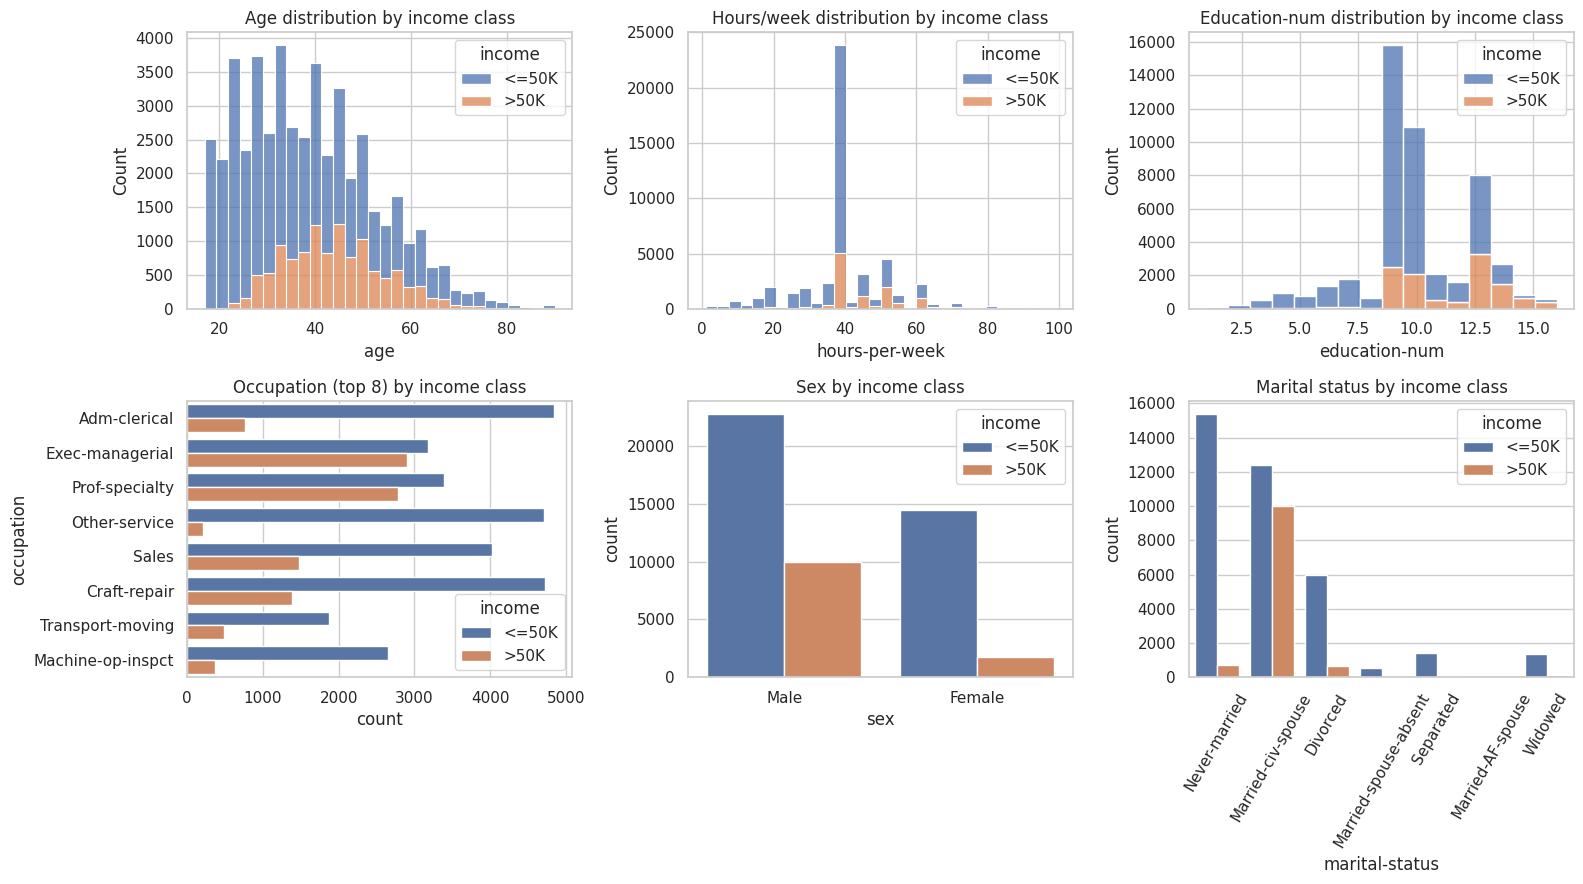

In [10]:
# Visualizations: histograms + bar plots
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.histplot(data=df, x="age", hue="income", multiple="stack", bins=30, ax=axes[0,0])
axes[0,0].set_title("Age distribution by income class")

sns.histplot(data=df, x="hours-per-week", hue="income", multiple="stack", bins=30, ax=axes[0,1])
axes[0,1].set_title("Hours/week distribution by income class")

sns.histplot(data=df, x="education-num", hue="income", multiple="stack", bins=16, ax=axes[0,2])
axes[0,2].set_title("Education-num distribution by income class")

top_occ = df["occupation"].value_counts().head(8).index
sns.countplot(data=df[df["occupation"].isin(top_occ)], y="occupation", hue="income", ax=axes[1,0])
axes[1,0].set_title("Occupation (top 8) by income class")

sns.countplot(data=df, x="sex", hue="income", ax=axes[1,1])
axes[1,1].set_title("Sex by income class")

sns.countplot(data=df, x="marital-status", hue="income", ax=axes[1,2])
axes[1,2].set_title("Marital status by income class")
axes[1,2].tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=120, bbox_inches="tight")
plt.show()

**EDA takeaways:** The classes are imbalanced (~24% positive). Higher income is visibly associated with more years of education (`education-num`), more hours worked per week, older age (up to a point), being married, and certain occupations (`Exec-managerial`, `Prof-specialty`). `workclass`, `occupation`, and `native-country` all have missing values that need handling before modeling.

## Task 3 — Create Reproducible Splits

We carve out a **20% stratified hold-out test set** with a fixed `random_state=42`, and split the remaining 80% into a **10% dev set** and a **70% training set** (also stratified). The hold-out test set is set aside now and is **not touched again** until final evaluation.

**Why a hold-out test is necessary:** If we tune hyperparameters or select features by repeatedly checking performance on the same data we'll report our final number on, we implicitly "leak" information about that data into our modeling choices — we end up picking the settings that happen to fit that particular sample best, not the settings that generalize. The reported metric then overstates real-world performance (optimistic bias), and the gap can be large enough to make a genuinely mediocre model look production-ready. Using the hold-out set only once, at the very end, keeps our final performance estimate honest.

In [11]:
X = df.drop(columns=["target","income"])
y = df["target"]

# 80% train+dev / 20% hold-out test, stratified on target
X_trainfull, X_test, y_trainfull, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# Split remaining 80% into ~10% dev + ~70% train (dev = 0.125 of the 80% -> 10% of total)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_trainfull, y_trainfull, test_size=0.125, stratify=y_trainfull, random_state=RANDOM_STATE
)

for name, y_split in [("train", y_train), ("dev", y_dev), ("test (hold-out)", y_test)]:
    print(f"{name:16s} n={len(y_split):6d}  positive rate={y_split.mean():.3%}")

train            n= 34188  positive rate=23.927%
dev              n=  4885  positive rate=23.930%
test (hold-out)  n=  9769  positive rate=23.933%


## Task 4 — Implement Simple Baselines

Two baselines, evaluated **only** on the hold-out test set:

1. **Majority-class predictor** — always predicts `<=50K` (the majority class), giving a floor accuracy equal to the base rate's complement.
2. **Single-feature rule** — `education-num >= 13` (roughly "Bachelor's degree or higher"). Justification: the EDA showed `education-num` is one of the most cleanly separated features between classes, and a Bachelor's-or-above cutoff is an intuitive, explainable business rule a stakeholder can sanity-check without a model.

In [12]:
def evaluate(y_true, y_pred, name):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_pred),
        "pr_auc": average_precision_score(y_true, y_pred),
    }

# Baseline 1: majority class
majority_pred = np.zeros_like(y_test)  # always predicts 0 (<=50K), since it's the majority class

# Baseline 2: single-feature rule
rule_pred = (X_test["education-num"] >= 13).astype(int).values

results = pd.DataFrame([
    evaluate(y_test, majority_pred, "Majority-class predictor"),
    evaluate(y_test, rule_pred, "Rule: education-num >= 13"),
]).set_index("model").round(4)

results

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Majority-class predictor,0.7607,0.0000,0.0000,0.0000,0.5000,0.2393
Rule: education-num >= 13,0.7465,0.4722,0.5004,0.4859,0.6622,0.3558


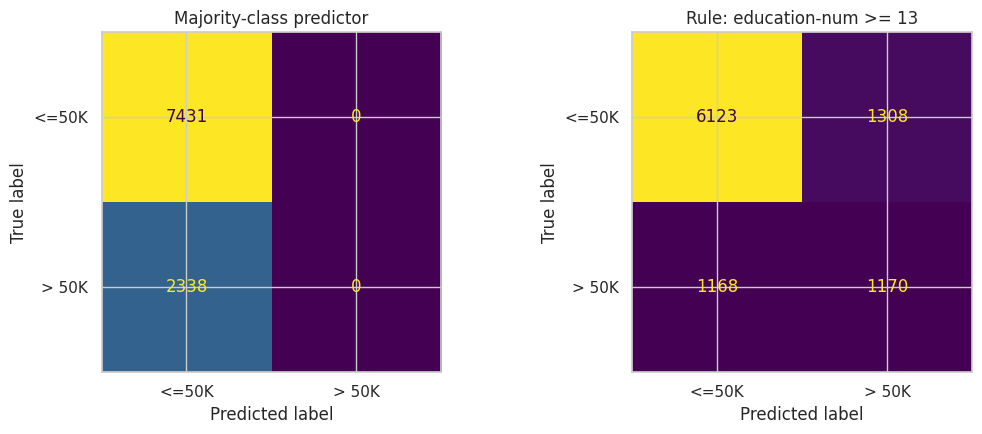

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, pred, title in zip(
    axes,
    [majority_pred, rule_pred],
    ["Majority-class predictor", "Rule: education-num >= 13"]
):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["<=50K","> 50K"]).plot(ax=ax, colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.savefig("baseline_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

**Interpretation:** The majority-class predictor reaches high *accuracy* purely by exploiting class imbalance, but it has **zero precision and zero recall on the positive class** — it is useless for the actual business goal of finding high earners, despite its accuracy number looking deceptively strong. The single-feature rule (`education-num >= 13`) trades some accuracy for genuinely useful precision/recall on the positive class, confirming education level alone captures real signal.

Given the rule baseline's precision, a real model needs to **clear that precision bar by a meaningful margin** (a rough target: **+10-15 points of precision** over the rule, while not collapsing recall to near zero) to be worth deploying — otherwise a single `if` statement is doing the job just as well, and there's no justification for the added complexity, latency, and maintenance cost of a trained model.

## Task 5 — Initial Error Analysis & Next Steps

Using the rule-based baseline (the more informative of the two), we sample false positives and false negatives from the hold-out test set to look for patterns.

In [14]:
test_analysis = X_test.copy()
test_analysis["y_true"] = y_test.values
test_analysis["y_pred"] = rule_pred

false_positives = test_analysis[(test_analysis.y_true == 0) & (test_analysis.y_pred == 1)]
false_negatives = test_analysis[(test_analysis.y_true == 1) & (test_analysis.y_pred == 0)]

print(f"False positives: {len(false_positives)}  |  False negatives: {len(false_negatives)}")

cols_to_show = ["age","workclass","education","education-num","occupation",
                 "hours-per-week","capital-gain","marital-status"]

print("\n--- Sample of 10 False Positives (predicted >50K, actually <=50K) ---")
display(false_positives[cols_to_show].sample(10, random_state=RANDOM_STATE))

print("\n--- Sample of 10 False Negatives (predicted <=50K, actually >50K) ---")
display(false_negatives[cols_to_show].sample(10, random_state=RANDOM_STATE))

False positives: 1308  |  False negatives: 1168

--- Sample of 10 False Positives (predicted >50K, actually <=50K) ---


,age,workclass,education,education-num,occupation,hours-per-week,capital-gain,marital-status
14305,25,Private,Masters,14,Adm-clerical,40,0,Never-married
17170,40,Private,Bachelors,13,Exec-managerial,30,0,Never-married
34983,41,Federal-gov,Masters,14,Prof-specialty,40,0,Never-married
38264,45,Private,Bachelors,13,Craft-repair,50,0,Married-civ-spouse
48796,27,Private,Bachelors,13,Prof-specialty,52,2202,Never-married
24618,32,Private,Bachelors,13,Farming-fishing,60,0,Married-civ-spouse
23049,65,Private,Bachelors,13,Exec-managerial,40,0,Never-married
21296,27,Private,Masters,14,Prof-specialty,45,0,Never-married
39311,37,Private,Bachelors,13,Exec-managerial,40,0,Married-spouse-absent
28958,36,Private,Bachelors,13,Other-service,35,0,Separated



--- Sample of 10 False Negatives (predicted <=50K, actually >50K) ---


,age,workclass,education,education-num,occupation,hours-per-week,capital-gain,marital-status
13554,39,Private,HS-grad,9,Machine-op-inspct,42,0,Married-civ-spouse
42793,60,Self-emp-not-inc,Some-college,10,Farming-fishing,50,0,Married-civ-spouse
1795,33,Private,HS-grad,9,Sales,40,3103,Married-civ-spouse
37641,44,Self-emp-not-inc,5th-6th,3,Farming-fishing,84,0,Married-civ-spouse
38,31,Private,Some-college,10,Sales,38,0,Married-civ-spouse
15507,47,Private,HS-grad,9,Sales,45,0,Married-civ-spouse
22643,57,Private,Some-college,10,Exec-managerial,45,7688,Married-civ-spouse
39873,53,Private,HS-grad,9,Handlers-cleaners,40,0,Married-civ-spouse
1413,53,Private,Some-college,10,Exec-managerial,45,0,Married-civ-spouse
8151,45,Private,HS-grad,9,Exec-managerial,60,0,Married-civ-spouse


In [15]:
# Look for patterns in the error groups vs. the overall test set
print("False positives — mean hours/week: %.1f  |  mean age: %.1f  |  capital-gain>0: %.1f%%" % (
    false_positives["hours-per-week"].mean(), false_positives["age"].mean(),
    (false_positives["capital-gain"] > 0).mean() * 100))

print("False negatives — mean hours/week: %.1f  |  mean age: %.1f  |  capital-gain>0: %.1f%%" % (
    false_negatives["hours-per-week"].mean(), false_negatives["age"].mean(),
    (false_negatives["capital-gain"] > 0).mean() * 100))

print("\nFalse negative marital-status breakdown:")
print(false_negatives["marital-status"].value_counts(normalize=True).round(3))

print("\nFalse positive marital-status breakdown:")
print(false_positives["marital-status"].value_counts(normalize=True).round(3))

False positives — mean hours/week: 40.1  |  mean age: 37.8  |  capital-gain>0: 5.4%
False negatives — mean hours/week: 44.4  |  mean age: 44.3  |  capital-gain>0: 20.5%

False negative marital-status breakdown:
marital-status
Married-civ-spouse       0.890
Divorced                 0.045
Never-married            0.040
Widowed                  0.012
Separated                0.009
Married-spouse-absent    0.004
Name: proportion, dtype: float64

False positive marital-status breakdown:
marital-status
Never-married            0.503
Married-civ-spouse       0.290
Divorced                 0.152
Separated                0.021
Widowed                  0.019
Married-spouse-absent    0.015
Name: proportion, dtype: float64


**Observed patterns:**
- **False negatives** (educated below Bachelor's but still earn >50K) skew toward *higher* hours-per-week and non-trivial `capital-gain`, and are disproportionately `Married-civ-spouse` — i.e. the rule misses self-made / capital-income / overtime earners without a 4-year degree.
- **False positives** (Bachelor's+ but earn <=50K) skew toward *younger* individuals and lower hours-per-week — early-career graduates or part-time workers the rule over-credits based on education alone.

**Data/feature issues to fix tomorrow:**
1. **Missing values** in `workclass`, `occupation`, `native-country` (~2-6% each) — need an explicit `"Unknown"` category rather than silent drop, since missingness itself may be predictive.
2. **High-cardinality categoricals** (`native-country` has ~42 levels, heavily dominated by `United-States`) — needs grouping into a smaller set (e.g. US / other-region buckets) before one-hot encoding to avoid sparse, noisy columns.
3. **Skewed numerics** — `capital-gain` and `capital-loss` are extremely zero-inflated and right-skewed; consider a log1p transform or binarizing into "has capital gain/loss" flags.
4. **`fnlwgt`** is a census sampling weight, not a real-world feature about the individual — likely should be excluded from the feature set (risk of spurious signal / leakage-like behavior).
5. **`education` vs `education-num`** are redundant (same information, categorical vs ordinal) — keep only one to avoid double-counting the same signal.
6. **Class imbalance** (~24% positive) — plan to compare class-weighting vs. resampling (e.g. `class_weight='balanced'`) during model tuning, and make sure the dev set (not the hold-out test) is used for that comparison.

**Primary metric for the rest of the week: Precision** (positive class), tracked alongside ROC AUC as a threshold-independent secondary check. The rule baseline already shows meaningful precision is achievable from a single feature; a real model's job is to raise precision substantially above that bar — ideally with materially better recall too — since a low-precision model directly translates into wasted outreach cost, which is the metric the business objective (Task 1) is built around. All further tuning will happen against the **dev set only**, with the hold-out test set reserved for the final, one-time evaluation at the end of the week.